# Notebook 00 — Setup and Environment

**CIE-552 Computer Vision Term Project**
*Driver Assistance: Eye-State Classification (Samsung S24 Ultra) + Lane-Direction Classification (Raspberry Pi 4)*

This notebook is the entry point. It:

1. Pins reproducibility (fixed seeds for `random`, `numpy`, `torch`, `tensorflow`).
2. Prints versions of every library that subsequent notebooks rely on, so you can detect drift early.
3. Confirms GPU availability for training notebooks (03+).
4. Walks every dataset folder we will use and **visualizes one sample per source** so the data is sanity-checked end-to-end before any model is trained.

Run order for the whole project: **00 → eye/01..08 → lane/01..08 → 09**. Each later notebook assumes 00 has been executed in the same session is not required (notebooks are self-contained), but 00 documents the canonical environment.

## 1. Reproducibility — fix all seeds to 42

Per PDF §5 (Experimental Protocol) every experiment must be reproducible.
We fix Python's `random`, NumPy, PyTorch (CPU + CUDA), and TensorFlow seeds.
Each downstream notebook re-applies these seeds in its first code cell so it can be run standalone.

In [1]:
import os, random, hashlib
import numpy as np

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Verify by hashing 10 random draws
state_hash = hashlib.sha1(np.random.bytes(64)).hexdigest()[:16]
print(f"SEED              = {SEED}")
print(f"numpy state hash  = {state_hash}  (should be stable across runs)")

SEED              = 42
numpy state hash  = e3406ae76fe57c40  (should be stable across runs)


In [2]:
import torch
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"torch seed applied; deterministic cudnn = {torch.backends.cudnn.deterministic}")

torch seed applied; deterministic cudnn = True


In [3]:
# TF seed (TF 2.20). tf.keras.utils.set_random_seed seeds Python, NumPy and TF.
import tensorflow as tf
tf.keras.utils.set_random_seed(SEED)
# Optional: enable deterministic ops (slower but exact). Off here to keep training tractable.
# tf.config.experimental.enable_op_determinism()
print(f"tensorflow seed applied: {SEED}")

tensorflow seed applied: 42


## 2. Library versions (drift check)

If any of the following differs significantly from a teammate's machine, expect numerical drift in results.

In [4]:
import sys, platform
import numpy, cv2, sklearn, matplotlib, skimage, albumentations, seaborn, pandas, onnxruntime
import torch, tensorflow

print(f"Python           {sys.version.split()[0]}  ({platform.platform()})")
print(f"numpy            {numpy.__version__}")
print(f"opencv (cv2)     {cv2.__version__}")
print(f"scikit-learn     {sklearn.__version__}")
print(f"matplotlib       {matplotlib.__version__}")
print(f"scikit-image     {skimage.__version__}")
print(f"albumentations   {albumentations.__version__}")
print(f"seaborn          {seaborn.__version__}")
print(f"pandas           {pandas.__version__}")
print(f"onnxruntime      {onnxruntime.__version__}")
print(f"torch            {torch.__version__}")
print(f"tensorflow       {tensorflow.__version__}")

Python           3.13.7  (Windows-11-10.0.26200-SP0)
numpy            2.3.5
opencv (cv2)     4.13.0
scikit-learn     1.7.2
matplotlib       3.10.1
scikit-image     0.26.0
albumentations   2.0.8
seaborn          0.13.2
pandas           2.2.3
onnxruntime      1.20.1
torch            2.6.0+cu124
tensorflow       2.20.0


## 3. Device map

Eye and Lane training notebooks expect a CUDA GPU on the workstation.
On-device inference benchmarks for the **Samsung S24 Ultra** (NNAPI + GPU delegates) and the **Raspberry Pi 4B** (TFLite/XNNPACK and OpenVINO ARM-CPU plugin) are done in the deployment notebooks (08-eye and 08-lane) and do **not** require those devices to be attached for the training-side work.

In [5]:
print("=== PyTorch device map ===")
print(f"CUDA available     : {torch.cuda.is_available()}")
print(f"CUDA device count  : {torch.cuda.device_count()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        print(f"  [{i}] {p.name}  ({p.total_memory/1e9:.1f} GB, CC {p.major}.{p.minor})")

print("\n=== TensorFlow device map ===")
for d in tf.config.list_physical_devices():
    print(f"  {d.device_type:5s}  {d.name}")

=== PyTorch device map ===
CUDA available     : True
CUDA device count  : 1
  [0] NVIDIA GeForce RTX 3060 Laptop GPU  (6.4 GB, CC 8.6)

=== TensorFlow device map ===
  CPU    /physical_device:CPU:0


## 4. Dataset paths and existence checks

We touch every folder declared in §1 of the plan and confirm it exists with the expected file count. This catches the single most common pre-training failure: a path that does not exist or a relabelled folder.

In [6]:
from pathlib import Path

ROOT = Path.cwd()
print(f"Project root: {ROOT}\n")

PATHS = {
    "cew_closed":       ROOT / "datasets" / "CEW" / "cropped" / "dataset_B_FacialImages" / "ClosedFace",
    "cew_open":         ROOT / "datasets" / "CEW" / "cropped" / "dataset_B_FacialImages" / "OpenFace",
    "cew_fullres":      ROOT / "datasets" / "CEW" / "full res" / "dataset_B_FacialImages_highResolution",
    "tusimple_frames":  ROOT / "datasets" / "tusimple" / "training" / "frames",
    "tusimple_masks":   ROOT / "datasets" / "tusimple" / "training" / "lane-masks",
    "cew_finetune":     ROOT / "fine_tuning" / "CEW_fine_tuning",
    "lane_ft_images":   ROOT / "fine_tuning" / "lane_fine_tuning" / "segmentation_dataset" / "images",
    "lane_ft_masks":    ROOT / "fine_tuning" / "lane_fine_tuning" / "segmentation_dataset" / "masks",
    "lane_ft_videos":   ROOT / "fine_tuning" / "lane_fine_tuning" / "videos",
}

EXPECTED = {
    "cew_closed": 1192, "cew_open": 1231, "cew_fullres": 1192,
    "tusimple_frames": 3626, "tusimple_masks": 3626,
    "cew_finetune": 12,
    "lane_ft_images": 10500, "lane_ft_masks": 10500, "lane_ft_videos": 6,
}

IMG_OR_VIDEO = {".jpg", ".jpeg", ".png", ".bmp", ".mp4", ".json"}

import pandas as pd
rows = []
for key, p in PATHS.items():
    exists = p.exists()
    n = sum(1 for f in p.iterdir() if f.is_file() and f.suffix.lower() in IMG_OR_VIDEO) if exists else 0
    expected = EXPECTED[key]
    ok = exists and (n == expected)
    rows.append({"asset": key, "path": str(p.relative_to(ROOT)), "exists": exists,
                 "n_files": n, "expected": expected, "ok": ok})

inv = pd.DataFrame(rows)
display(inv)
assert inv["ok"].all(), "Dataset inventory mismatch — check rows where ok=False."
print("All dataset folders verified.")

Project root: D:\Spring forth year\Computer Vision\project



,asset,path,exists,n_files,expected,ok
0,cew_closed,datasets\CEW\cropped\dataset_B_FacialImages\Cl...,True,1192,1192,True
1,cew_open,datasets\CEW\cropped\dataset_B_FacialImages\Op...,True,1231,1231,True
2,cew_fullres,datasets\CEW\full res\dataset_B_FacialImages_h...,True,1192,1192,True
3,tusimple_frames,datasets\tusimple\training\frames,True,3626,3626,True
4,tusimple_masks,datasets\tusimple\training\lane-masks,True,3626,3626,True
5,cew_finetune,fine_tuning\CEW_fine_tuning,True,12,12,True
6,lane_ft_images,fine_tuning\lane_fine_tuning\segmentation_data...,True,10500,10500,True
7,lane_ft_masks,fine_tuning\lane_fine_tuning\segmentation_data...,True,10500,10500,True
8,lane_ft_videos,fine_tuning\lane_fine_tuning\videos,True,6,6,True


All dataset folders verified.


## 5. Visual sanity check — one sample per source

This is the **single most useful figure in the whole project**: if any panel below looks wrong (mis-cropped, channel-swapped, wrong domain), every later notebook will inherit the error.

- Row 1: CEW cropped (closed / open)
- Row 2: CEW full-res (closed) + CEW phone-capture fine-tuning (S24 Ultra)
- Row 3: TuSimple frame + TuSimple lane-mask + Lane fine-tune image + Lane fine-tune mask

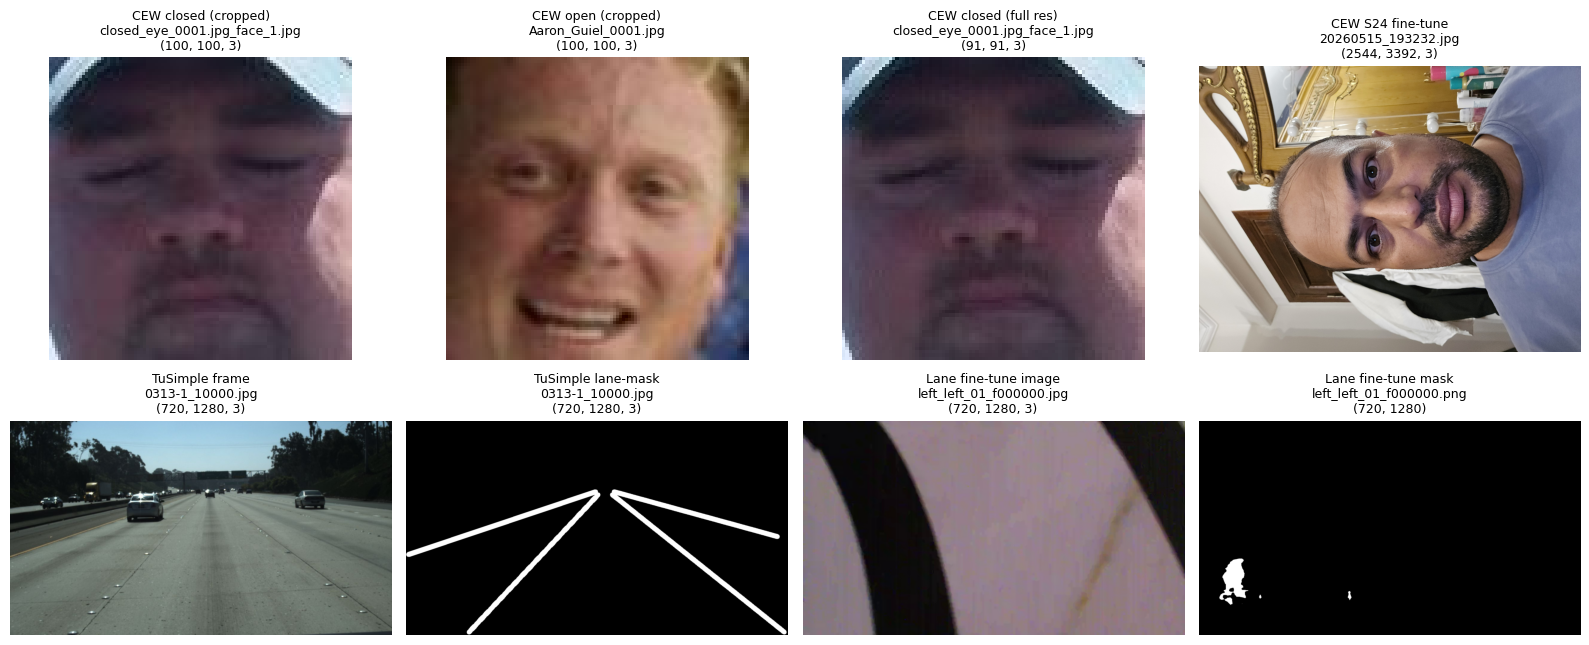

Saved: artifacts/00_dataset_samples.png


In [7]:
import matplotlib.pyplot as plt
import cv2

def first_image(p: Path):
    for f in sorted(p.iterdir()):
        if f.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}:
            img = cv2.imread(str(f), cv2.IMREAD_UNCHANGED)
            if img is None:
                continue
            if img.ndim == 3:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            return f.name, img
    raise FileNotFoundError(f"No image in {p}")

panels = [
    ("CEW closed (cropped)",    PATHS["cew_closed"]),
    ("CEW open (cropped)",      PATHS["cew_open"]),
    ("CEW closed (full res)",   PATHS["cew_fullres"]),
    ("CEW S24 fine-tune",       PATHS["cew_finetune"]),
    ("TuSimple frame",          PATHS["tusimple_frames"]),
    ("TuSimple lane-mask",      PATHS["tusimple_masks"]),
    ("Lane fine-tune image",    PATHS["lane_ft_images"]),
    ("Lane fine-tune mask",     PATHS["lane_ft_masks"]),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (title, p) in zip(axes.ravel(), panels):
    name, img = first_image(p)
    cmap = "gray" if img.ndim == 2 else None
    ax.imshow(img, cmap=cmap)
    ax.set_title(f"{title}\n{name}\n{img.shape}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "00_dataset_samples.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: artifacts/00_dataset_samples.png")

## 6. Manifest — paths exported for downstream notebooks

Downstream notebooks can re-derive these paths trivially, but we also dump a JSON manifest into `artifacts/` so paths are auditable from a single file.

In [8]:
import json

manifest = {
    "seed": SEED,
    "paths": {k: str(v.relative_to(ROOT)) for k, v in PATHS.items()},
    "expected_counts": EXPECTED,
}
(ROOT / "artifacts").mkdir(exist_ok=True)
with open(ROOT / "artifacts" / "00_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)
print(json.dumps(manifest, indent=2))

{
  "seed": 42,
  "paths": {
    "cew_closed": "datasets\\CEW\\cropped\\dataset_B_FacialImages\\ClosedFace",
    "cew_open": "datasets\\CEW\\cropped\\dataset_B_FacialImages\\OpenFace",
    "cew_fullres": "datasets\\CEW\\full res\\dataset_B_FacialImages_highResolution",
    "tusimple_frames": "datasets\\tusimple\\training\\frames",
    "tusimple_masks": "datasets\\tusimple\\training\\lane-masks",
    "cew_finetune": "fine_tuning\\CEW_fine_tuning",
    "lane_ft_images": "fine_tuning\\lane_fine_tuning\\segmentation_dataset\\images",
    "lane_ft_masks": "fine_tuning\\lane_fine_tuning\\segmentation_dataset\\masks",
    "lane_ft_videos": "fine_tuning\\lane_fine_tuning\\videos"
  },
  "expected_counts": {
    "cew_closed": 1192,
    "cew_open": 1231,
    "cew_fullres": 1192,
    "tusimple_frames": 3626,
    "tusimple_masks": 3626,
    "cew_finetune": 12,
    "lane_ft_images": 10500,
    "lane_ft_masks": 10500,
    "lane_ft_videos": 6
  }
}


## What's next

- `eye/01_eye_data_exploration.ipynb` — full EDA of the CEW dataset, stratified split, class-balance plots.
- `lane/01_lane_data_exploration.ipynb` — parse TuSimple JSON, derive direction labels, lane-mask vs polyline cross-check, video-level splits.